In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

In [75]:
df=pd.read_csv('/content/hospital_readmission.csv')

In [76]:
df.head()

,age,length_of_stay_days,num_diagnoses,num_medications,prev_admissions,glucose_level,bmi,has_diabetes,discharge_type,readmitted_30days
0,22,28.0,2.0,13.0,4.0,89.1,48.4,1.0,2.0,0
1,44,12.0,7.0,11.0,2.0,254.8,23.9,1.0,0.0,1
2,34,15.0,9.0,16.0,6.0,270.2,16.7,0.0,1.0,1
3,39,15.0,5.0,16.0,6.0,208.6,18.2,0.0,1.0,1
4,62,24.0,1.0,6.0,6.0,233.1,44.0,0.0,0.0,1


In [77]:
df.shape

(32300, 10)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  31653 non-null  object 
 1   length_of_stay_days  31652 non-null  float64
 2   num_diagnoses        31655 non-null  float64
 3   num_medications      31654 non-null  float64
 4   prev_admissions      31654 non-null  float64
 5   glucose_level        31654 non-null  float64
 6   bmi                  31654 non-null  float64
 7   has_diabetes         31653 non-null  float64
 8   discharge_type       31655 non-null  float64
 9   readmitted_30days    32300 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 2.5+ MB


In [79]:
df.describe()

,length_of_stay_days,num_diagnoses,num_medications,prev_admissions,glucose_level,bmi,has_diabetes,discharge_type,readmitted_30days
count,31652.000000,31655.000000,31654.00000,31654.000000,31654.000000,31654.000000,31653.000000,31655.000000,32300.000000
mean,15.008846,7.529521,10.05418,4.500916,179.799055,32.571947,0.355195,0.998136,0.499659
std,8.394087,4.023350,5.57273,2.865609,69.854520,10.098815,0.478580,0.815959,0.500008
min,1.000000,1.000000,1.00000,0.000000,60.000000,-5.000000,0.000000,0.000000,0.000000
25%,8.000000,4.000000,5.00000,2.000000,119.000000,23.900000,0.000000,0.000000,0.000000
50%,15.000000,8.000000,10.00000,5.000000,179.900000,32.600000,0.000000,1.000000,0.000000
75%,22.000000,11.000000,15.00000,7.000000,240.700000,41.200000,1.000000,2.000000,1.000000
max,29.000000,14.000000,200.00000,9.000000,900.000000,50.000000,1.000000,2.000000,1.000000


#Data Preprocessing

1. Handling NULL values


In [80]:
#object to int
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [81]:
print(df.isnull().sum())

age                    727
length_of_stay_days    648
num_diagnoses          645
num_medications        646
prev_admissions        646
glucose_level          646
bmi                    646
has_diabetes           647
discharge_type         645
readmitted_30days        0
dtype: int64


In [82]:
#categorical columns
df["has_diabetes"] = df["has_diabetes"].fillna(
    df["has_diabetes"].mode()[0]
)

df["discharge_type"] = df["discharge_type"].fillna(
    df["discharge_type"].mode()[0]
)

In [83]:
# Numerical columns
numerical_cols = [
    "age",
    "length_of_stay_days",
    "num_diagnoses",
    "num_medications",
    "prev_admissions",
    "glucose_level",
    "bmi"
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [84]:
df.head(10)

,age,length_of_stay_days,num_diagnoses,num_medications,prev_admissions,glucose_level,bmi,has_diabetes,discharge_type,readmitted_30days
0,22.0,28.0,2.0,13.0,4.0,89.1,48.4,1.0,2.0,0
1,44.0,12.0,7.0,11.0,2.0,254.8,23.9,1.0,0.0,1
2,34.0,15.0,9.0,16.0,6.0,270.2,16.7,0.0,1.0,1
3,39.0,15.0,5.0,16.0,6.0,208.6,18.2,0.0,1.0,1
4,62.0,24.0,1.0,6.0,6.0,233.1,44.0,0.0,0.0,1
5,150.0,10.0,7.0,18.0,8.0,268.9,25.9,0.0,0.0,0
6,48.0,22.0,4.0,19.0,5.0,177.2,17.3,0.0,1.0,1
7,88.0,22.0,2.0,19.0,6.0,128.0,42.8,1.0,2.0,1
8,39.0,2.0,12.0,15.0,1.0,252.8,15.6,0.0,0.0,0
9,70.0,29.0,5.0,11.0,9.0,102.5,23.9,0.0,0.0,1


In [85]:
print(df.isnull().sum())

age                    0
length_of_stay_days    0
num_diagnoses          0
num_medications        0
prev_admissions        0
glucose_level          0
bmi                    0
has_diabetes           0
discharge_type         0
readmitted_30days      0
dtype: int64


3. Data Splitting before Scaling

In [86]:
X = df.drop("readmitted_30days", axis=1)
y = df["readmitted_30days"]

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

4. Scaling

In [88]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

5. Logistic Regression with L2 regularization

In [89]:
lr = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000
)

In [90]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

6. Predictions

In [91]:
y_prob = lr.predict_proba(X_test)[:, 1]

In [92]:
y_pred = lr.predict(X_test)

7. Evaluations

AUC-ROC:  0.8755641770032021 



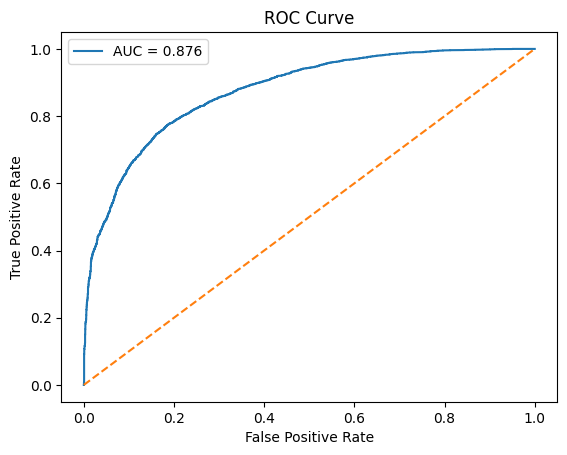

In [93]:
#AUC-ROC Curve
auc = roc_auc_score(y_test, y_prob)
print('AUC-ROC: ',auc,'\n')
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [94]:
#Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[2573  659]
 [ 686 2542]]


In [95]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79      3232
           1       0.79      0.79      0.79      3228

    accuracy                           0.79      6460
   macro avg       0.79      0.79      0.79      6460
weighted avg       0.79      0.79      0.79      6460



The model produced 686 false negatives and 659 false positives. False negatives are clinically important because they represent patients who were actually readmitted but were predicted as low risk, potentially causing missed opportunities for additional monitoring and preventive care. False positives represent patients predicted to be readmitted who were not, which may result in unnecessary healthcare resources being used. Since the number of false negatives (686) is slightly higher than false positives (659), reducing missed high-risk patients may be an important consideration when selecting the classification threshold.

8. Save predictions

In [96]:
predictions = pd.DataFrame({
    "readmission_probability": y_prob,
    "readmitted_30days": y_pred
})

predictions.to_csv("predictions.csv", index=False)